# Проект\. Итоговый отчёт

## HR Analytics: Employee Attrition & Performance

Источник: Kaggle https://www\.kaggle\.com/datasets/pavansubhasht/ibm\-hr\-analytics\-attrition\-dataset/data

Описание: Датасет создан специалистами IBM и представляет собой синтетические \(но реалистичные\) HR\-данные о 1470 сотрудниках компании\. Он содержит демографические характеристики, показатели удовлетворённости, данные о доходах, карьерных параметрах и информацию о том, покинул ли сотрудник компанию \(всего 35 колонок, из анализа были исключены признаки, не несущие полезной информации и/или не разъяснённые создателями\)\.

### Постановка задачи

Цель проекта — исследовать факторы, влияющие на текучесть кадров \(Attrition\) и определить, какие характеристики сотрудников повышают вероятность их ухода из компании\. Это необходимо для выявления групп риска и разработки мер по удержанию сотрудников\.

Целевая переменная: Attrition \(бинарная: Yes/No — факт ухода сотрудника из компании\)\.

Для решения этой задачи используется один основной подход — анализ взаимосвязей между переменными \(статистические тесты и регрессия\), а также два дополнительных: метод выделения подгрупп и построение предсказательной модели, позволяющей оценивать вероятность ухода сотрудника, как дополнительный инструмент\.

Такое сочетание методов позволяет, с одной стороны, выявить статистически значимые взаимосвязи, а с другой — проверить, насколько эти факторы действительно важны с точки зрения предсказания\.

### Первичный анализ взаимосвязей \(статистические тесты\)

На первом этапе были проверены отдельные гипотезы о взаимосвязи факторов с текучестью кадров. Это позволяет понять, подтверждаются ли интуитивно логичные взаимосвязи, и стоит ли их вкючать в модель в дальнейшем.

Исследовательские вопросы, которые были проверены:
1. Связь между переработками и текучестью: Уходят ли сотрудники, которые работают сверхурочно, чаще остальных?
2. Доход и текучесть: Уходят ли чаще сотрудники с более низким уровнем месячного дохода?

#### Что выяснили?

##### Переработки и текучесть:

Сотрудники, работающие сверхурочно, статистически значимо чаще увольняются: разница составляет около 20 п.п. (p-value < 0.05).
Это указывает на сильную взаимосвязь между нагрузкой и уходом сотрудников.

##### Доход и текучесть:

Средний доход у оставшихся сотрудников статистически значимо выше, чем у ушедших (p-value < 0.05).
Следовательно, уровень дохода связан с вероятностью ухода.

Подробное исследование:

In [1]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 18.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as sm
from sklearn.preprocessing import StandardScaler

In [27]:
data = pd.read_csv("datasets/HR-Employee-Attrition.csv")
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'DailyRate', 'HourlyRate','MonthlyRate']
data = data.drop(columns=columns_to_drop)
binary_columns = ['Attrition', 'OverTime']
for col in binary_columns:
    data[col] = data[col].map({'Yes': 1, 'No': 0})
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,2,0,3,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,1,2,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,0,3,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,1,1,3,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,Research & Development,23,2,Medical,3,1,4,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,Research & Development,6,1,Medical,4,1,2,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,Research & Development,4,3,Life Sciences,2,1,4,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,Sales,2,3,Medical,4,1,2,...,3,4,0,17,3,2,9,6,0,8


> 1\. Связь между переработками и текучестью: Уходят ли сотрудники, которые работают сверхурочно, чаще остальных?

Нулевая гипотеза: Взаимосвязи между текучестью кадров и переработками нет\.

In [29]:
over_t = pd.crosstab(data['OverTime'], data['Attrition'])
over_t.columns = ['Stayed', 'Left']
over_t.index = ['No overtime', 'Overtime']
over_t

,Stayed,Left
No overtime,944,110
Overtime,289,127


In [30]:
over_percent = pd.crosstab(data['OverTime'], data['Attrition'], normalize='index')
over_percent.columns = ['Stayed', 'Left']
over_percent.index = ['No overtime', 'Overtime']
over_percent

,Stayed,Left
No overtime,0.895636,0.104364
Overtime,0.694712,0.305288


Статистический тест \(хи\-квадрат\):

In [31]:
stats.chi2_contingency(over_t)

Chi2ContingencyResult(statistic=87.56429365828768, pvalue=8.15842372153832e-21, dof=1, expected_freq=array([[884.06938776, 169.93061224],
       [348.93061224,  67.06938776]]))

In [32]:
print('Разница между долями ушедших сотрудников, работающих сверхурочно и не работающих сверхурочно: ', 
round((over_percent.iloc[1,1] - over_percent.iloc[0,1])*100,1),'процентных пунктов')

Разница между долями ушедших сотрудников, работающих сверхурочно и не работающих сверхурочно:  20.1 процентных пунктов


Вывод: Да, доля выгоревших и покинувших компанию сотрудников среди тех, кто работал сверхурочно, статистически значимо выше на 20\.1 п\.п\., чем среди тех, кто не перерабатывал, так как p\-value < 0\.05 \(8\.16\*10^\-21\), отвергаем нулевую гипотезу\. Это достаточно большая содержательная разница\.

> 2\. Доход и текучесть: Уходят ли чаще сотрудники с более низким уровнем месячного дохода?

Нулевая гипотеза: Средний доход у ушедших сотрудников не отличается от среднего дохода тех, кто продолжает работать\.

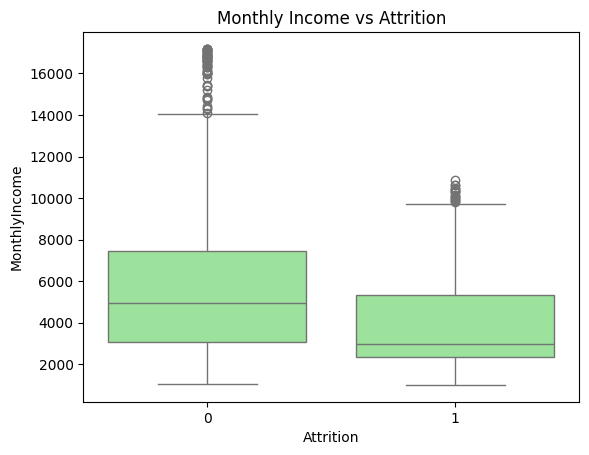

In [33]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

data_clean = data.groupby('Attrition').apply(lambda x: remove_outliers_iqr(x, 'MonthlyIncome')).reset_index(drop=True)

sns.boxplot(y='MonthlyIncome', x='Attrition', data=data_clean, color='lightgreen')
plt.title('Monthly Income vs Attrition')
plt.show()

In [34]:
data_clean.groupby("Attrition").MonthlyIncome.describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1151.0,5977.929626,3718.790921,1051.0,3056.0,4930.0,7449.0,17181.0
1,225.0,4204.493333,2582.554774,1009.0,2362.0,2973.0,5346.0,10854.0


Статистический тест \(t\-тест\):

In [35]:
left = data_clean.MonthlyIncome[(data_clean.Attrition==1)]
stayed = data_clean.MonthlyIncome[(data_clean.Attrition==0)]
stats.ttest_ind(left, stayed, nan_policy = "omit", equal_var=False)

TtestResult(statistic=-8.688958733468366, pvalue=7.798629829206156e-17, df=428.6727661340011)

In [36]:
print("Размер эффекта:",  stayed.mean() - left.mean())

Размер эффекта: 1773.4362930784828


Вывод: Мы отвергаем нулевую гипотезу, p\-value < 0\.05 \(7\.8\*10^\-17\), средний доход оставшихся сотрудников статистически значимо выше, чем у тех, кто покинул компанию \(разница тоже достаточно большая, если считать в долларах ~1700$\), такой результат наблюдается даже после удаления выбросов\.

Переработки и доход однозначно связанны с текучестью, поэтому они учитывались в дальнейших моделях\.

### Модель логистической регрессии

Для одновременного анализа множества факторов (их у нас действительно немало) была построена модель логистической регрессии, так как она позволяет оценивать вклад переменных в предсказание.

**Качество модели: Pseudo R² ≈ 0.29.** Модель существенно лучше, чем модель без предикторов. Это говорит о том, что модель адекватно описывает данные и может использоваться для анализа.

#### Основные результаты

Наиболее важные факторы с точки зрения предсказания:

- переработки,
- частота командировок,
- должность (особенно начальные позиции и продажи),
- возраст,
- количество предыдущих мест работы,
- длительность без повышения.

Факторы, снижающие вероятность ухода:

- высокая удовлетворённость (работой, средой, отношениями с коллегами),
- хороший баланс работы и личной жизни,
- наличие опционов,
- более высокий доход.

Уход сотрудников связан не с одним фактором, а с сочетанием условий работы, нагрузки, карьерных перспектив и удовлетворённости.

Подробнее:

In [38]:
from pandas.api.types import CategoricalDtype
cat_Travel = CategoricalDtype(categories=["Non-Travel","Travel_Rarely","Travel_Frequently"], ordered=True)
data['BusinessTravel'] = data['BusinessTravel'].astype(cat_Travel)

cat_Marital = CategoricalDtype(categories=["Single","Divorced","Married"], ordered=True)
data['MaritalStatus'] = data['MaritalStatus'].astype(cat_Marital)

for col in ["Department", "EducationField", "Gender", "JobRole", "OverTime", "StockOptionLevel"]:
    data[col] = data[col].astype("category")

Проверка на мультиколлинеарность: из независимых переменных между собой связаны возраст, количество лет работы, зарплата и уровень должности \(очевидные логические связи\)\. PercentSalaryHike \(процент повышения зарплаты\) сильно коррелирует с PerformanceRating, не будем включать в модель первую переменную\. Неожиданных сильных связей не обнаружено\.

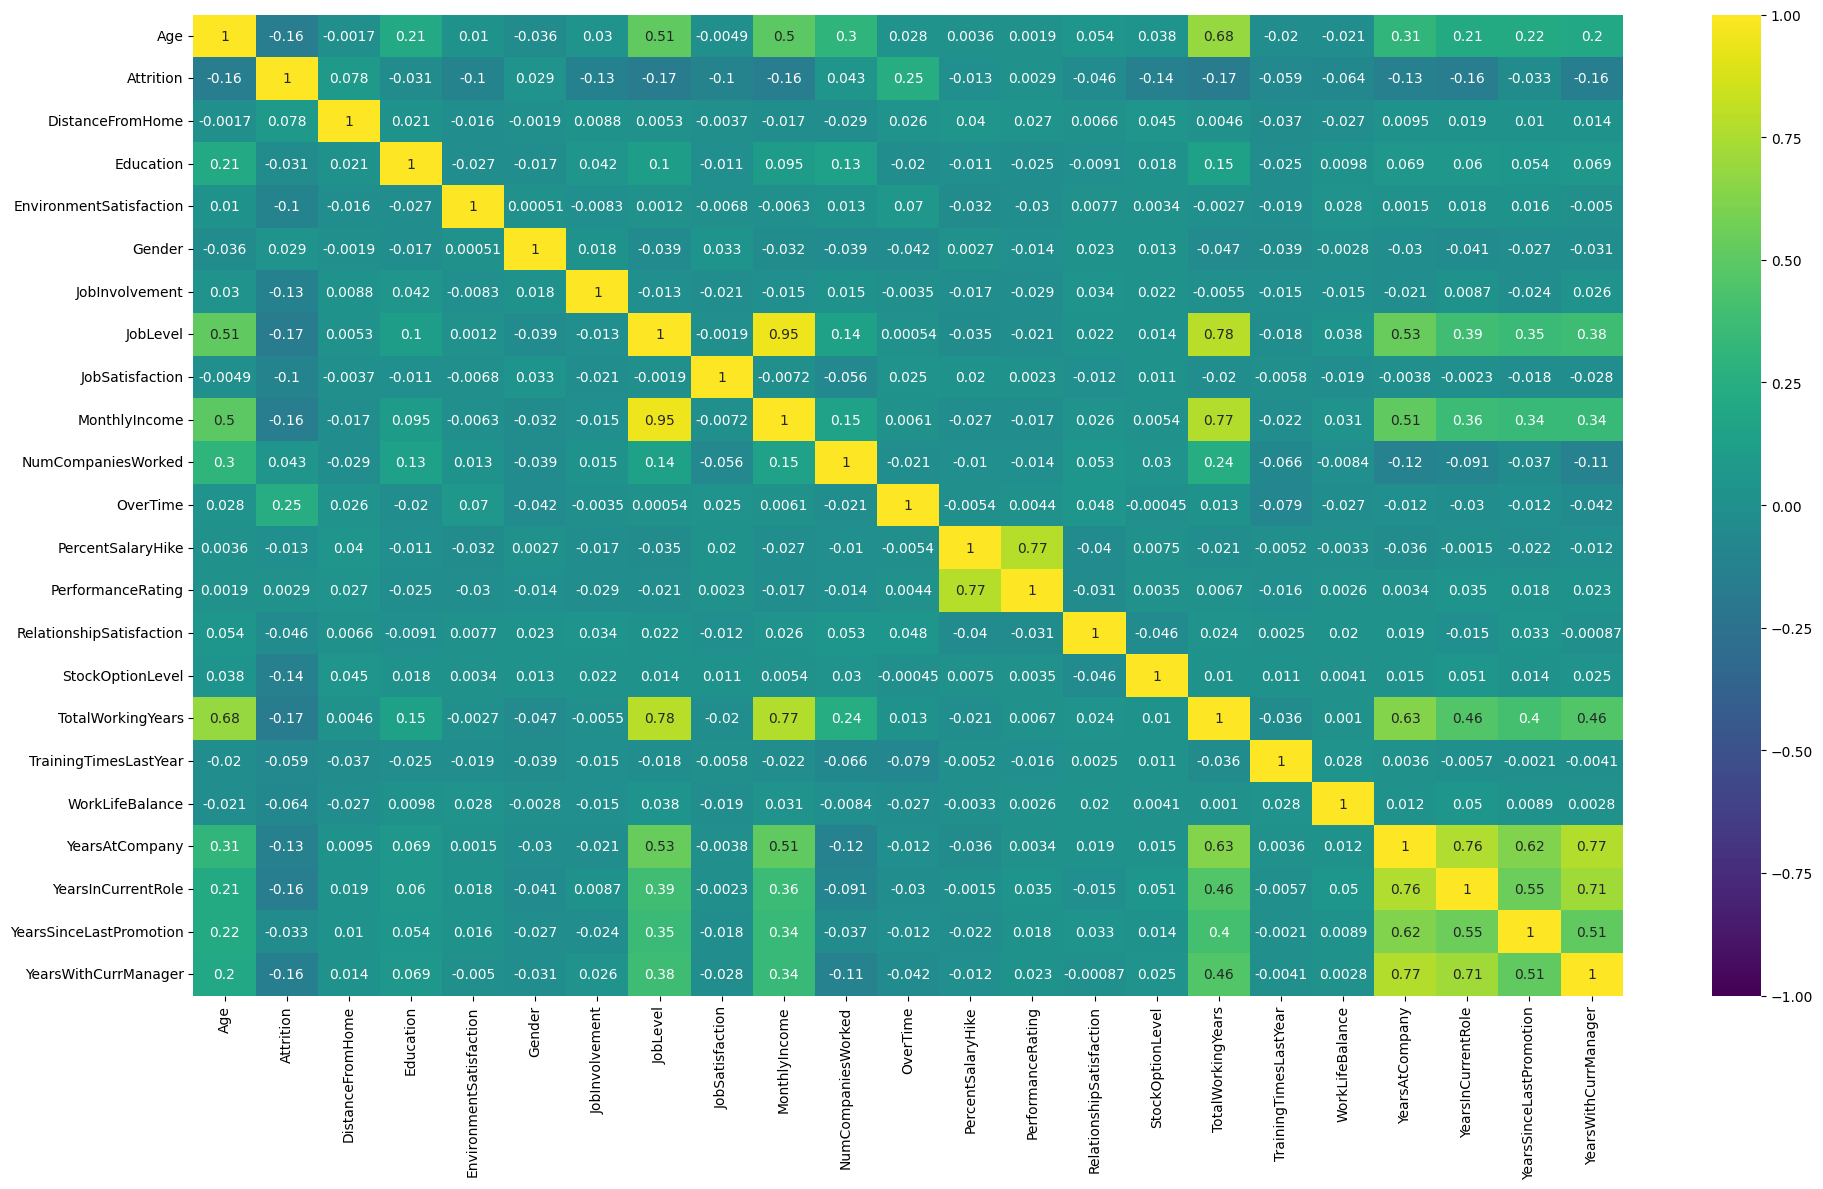

In [40]:
plt.figure(figsize=(20,12))
fig = sns.heatmap(data.drop(columns=['BusinessTravel', 'Department','EducationField', 'JobRole','MaritalStatus']).corr(),annot=True,cmap='viridis',vmin=-1.0,vmax=1.0)
plt.tight_layout()
plt.show(fig)

Сначала была построена тестовая модель, которая включала в себя почти все переменные, которые предположительно могли бы повлиять на исход, после оценки результата я избавилась от лишних \(не стат\. значимых\), в отчёте приведена только итоговая регрессия\.

Должности, у которых наблюдаются стат\. значимые коэффициенты, выделены отдельно, чтобы модель не была перегружена независимыми переменными:

In [42]:
data['Is_Lab_Tech'] = data['JobRole'].apply(lambda x: 1 if x == 'Laboratory Technician' else 0)
data['Is_Sales_Rep'] = data['JobRole'].apply(lambda x: 1 if x == 'Sales Representative' else 0)

Финальная модель \(Inference\):

Зависимые переменные: Age \+ BusinessTravel \+ DistanceFromHome \+ EnvironmentSatisfaction \+ Gender \+ Is\_Lab\_Tech \+ Is\_Sales\_Rep \+ JobInvolvement \+ JobSatisfaction \+ MonthlyIncome \+ NumCompaniesWorked \+ OverTime \+ RelationshipSatisfaction \+ StockOptionLevel \+ TrainingTimesLastYear \+ WorkLifeBalance \+ YearsSinceLastPromotion

In [44]:
formula = ("Attrition ~ Age + BusinessTravel + DistanceFromHome + EnvironmentSatisfaction + Gender + Is_Lab_Tech + Is_Sales_Rep + JobInvolvement + JobSatisfaction + MonthlyIncome + NumCompaniesWorked + OverTime + RelationshipSatisfaction + StockOptionLevel + TrainingTimesLastYear + WorkLifeBalance + YearsSinceLastPromotion")
model = sm.logit(formula=formula, data=data).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.313628
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1449
Method:                           MLE   Df Model:                           20
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                  0.2899
Time:                        13:35:29   Log-Likelihood:                -461.03
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 1.495e-67
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               3.2983      0.783      4.213      0.000       1.764       4.833
BusinessTravel[T.Travel_Rarely]         0.8448      0.356      2.372      0.018       0.147       1.543
BusinessTravel[T.Travel_Frequently]     1.6905      0.383      4.411      0.000       0.939       2.442
Gender[T.1]                             0.3917      0.176      2.224      0.026       0.047       0.737
OverTime[T.1]                           1.8111      0.182      9.944      0.000       1.454       2.168
StockOptionLevel[T.1]                  -1.2687      0.196     -6.484      0.000      -1.652      -0.885
StockOptionLevel[T.2]                  -1.4838      0.347     -4.280      0.000      -2.163      -0.804
StockOptionLevel[T.3]                  -0.6864      0.361     -1.900      0.057      -1.395       0.022
Age                                    -0.0496      0.012     -4.237      0.000      -0.073      -0.027
DistanceFromHome                        0.0415      0.010      4.050      0.000       0.021       0.062
EnvironmentSatisfaction                -0.3660      0.078     -4.693      0.000      -0.519      -0.213
Is_Lab_Tech                             0.7177      0.219      3.281      0.001       0.289       1.146
Is_Sales_Rep                            1.5341      0.312      4.915      0.000       0.922       2.146
JobInvolvement                         -0.5527      0.116     -4.772      0.000      -0.780      -0.326
JobSatisfaction                        -0.3614      0.077     -4.717      0.000      -0.512      -0.211
MonthlyIncome                       -8.889e-05   2.98e-05     -2.979      0.003      -0.000   -3.04e-05
NumCompaniesWorked                      0.1778      0.034      5.160      0.000       0.110       0.245
RelationshipSatisfaction               -0.2141      0.079     -2.713      0.007      -0.369      -0.059
TrainingTimesLastYear                  -0.1733      0.071     -2.443      0.015      -0.312      -0.034
WorkLifeBalance                        -0.3499      0.119     -2.948      0.003      -0.583      -0.117
YearsSinceLastPromotion                 0.0830      0.030      2.739      0.006       0.024       0.142
=======================================================================================================
"""

Преобразование всех коэффициентов в Odds Ratio \(отношение шансов\):

In [46]:
model_odds = pd.DataFrame(np.exp(model.params), columns= ['OR'])
model_odds['p-value'] = model.pvalues
model_odds[['2.5%', '97.5%']] = np.exp(model.conf_int())
model_odds

,OR,p-value,2.5%,97.5%
Intercept,27.066737,2.517037e-05,5.835565,125.541955
BusinessTravel[T.Travel_Rarely],2.327611,1.769379e-02,1.158059,4.678319
BusinessTravel[T.Travel_Frequently],5.422147,1.026644e-05,2.558520,11.490897
Gender[T.1],1.479529,2.611820e-02,1.047677,2.089390
OverTime[T.1],6.117297,2.669025e-23,4.280890,8.741482
StockOptionLevel[T.1],0.281201,8.908710e-11,0.191637,0.412626
StockOptionLevel[T.2],0.226775,1.872658e-05,0.114939,0.447427
StockOptionLevel[T.3],0.503361,5.749189e-02,0.247901,1.022071
Age,0.951608,2.261714e-05,0.930024,0.973693
DistanceFromHome,1.042336,5.131094e-05,1.021626,1.063465


Odds\-ratio для изменения месячного дохода на 1000$ \(в датасете доход измеряется долларами, а не тысячами долларов\):

In [48]:
np.exp(-0.00008889*1000)

0.9149462121225639

#### Качество модели
Модель демонстрирует достаточно хорошее качество для задач, связанных с прогнозированием ухода сотрудников. Значение Pseudo R² = 0.2899 означает, что модель объясняет около 29% вариации увольнений, что является вполне приемлемым результатом. Логарифм правдоподобия (Log-Likelihood = −461.03) статистически значимо выше (то есть менее отрицателен), чем LL-Null (−649.29), а это указывает на то, что модель существенно лучше, чем модель без предикторов, где все коэффициенты равны нулю.

В целом модель показывает, что увольнение сотрудников определяется сочетанием условий труда, нагрузки, политики вознаграждения, удовлетворённости и карьерного контекста.

#### Выводы о взаимосвязях переменных
Наиболее сильными предикторами увольнения оказались сверхурочная работа, частые командировки, а также роль в компании, особенно работа в продажах и лабораторных подразделениях. Эти факторы существенно повышают вероятность ухода и указывают на перегрузку или стресс, связанный с форматом работы.

Факторы, связанные с мотивацией и удовлетворённостью, снижают риск увольнения: высокая вовлечённость, удовлетворённость средой, работой, отношениями, а также благоприятный баланс работы и личной жизни оказывают выраженный положительный эффект на то, что сотрудник останется в компании. Финансовые стимулы также важны: наличие опционов на акции уменьшает вероятность ухода, а более высокий доход умеренно снижает риск.

Социально-демографические характеристики тоже имеют значимость. Молодые сотрудники и мужчины демонстрируют более высокие шансы на увольнение, а место проживания (расстояние до офиса) дополнительно усиливает риск ухода. Поведенческие и карьерные факторы, такие как количество предыдущих мест работы и длительность периода без повышения, также связаны с более высоким уровнем ухода сотрудников, но при этом семейное положение, отдел, образование и его уровень не показали статистически значимого влияния при включении в полную модель.

##### Интерпретация стат. значимых коэффициентов (p-value < 0,05):

- Gender = Male (OR = 1.48): У мужчин шансы ухода выше в 1,48 раза, чем у женщин (на 48% выше).
- Age (OR = 0.95) Каждый дополнительный год снижает шансы увольнения примерно на 4,8%. Шансы ухода у более молодых сотрудников существенно выше.
- DistanceFromHome (OR = 1.04): Каждый дополнительный километр увеличивает шансы увольнения на 4%. Эффект небольшой.
- BusinessTravel = Travel_Rarely (OR = 2.33): У сотрудников, которые редко ездят в командировки, шансы увольнения выше в 2,33 раза, чем у тех, кто совсем не ездит.
- BusinessTravel = Travel_Frequently (OR = 5.42): У сотрудников с частыми командировками шансы увольнения выше в 5,42 раза, чем у тех, кто не ездит в командировки. Это один из сильнейших эффектов в модели.
- OverTime (OR = 6.12): Сотрудники, работающие сверхурочно, имеют в 6,12 раза более высокие шансы увольнения, чем те, кто не работает сверхурочно. Это самый сильный поведенческий предиктор из всех.
- Is_Lab_Tech — лаборанты (OR = 2.05): У лаборантов шансы увольнения в 2,05 раза выше, чем у сотрудников других профессий.
- Is_Sales_Rep — рядовые сотрудники отдела продаж (OR = 4.64): У представителей продаж шансы увольнения в 4,64 раза выше. Это одна из самых проблемных групп.
- WorkLifeBalance – Баланс работы и личной жизни (OR = 0.70): Более высокий баланс снижает шансы увольнения на 30%.
- EnvironmentSatisfaction — Удовлетворённость рабочей средой (OR = 0.69): У сотрудников с более высокой удовлетворённостью рабочей средой шансы увольнения на 31% ниже.
- JobInvolvement — Увлечённость работой (OR = 0.58): Каждый дополнительный уровень вовлечённости снижает шансы ухода примерно на 42%.
- JobSatisfaction — Удовлетворённость работой (OR = 0.70): Более высокая удовлетворённость снижает шансы увольнения на 30%.
- RelationshipSatisfaction — Удовлетворённость отношениями с коллегами (OR = 0.81): Каждое повышение уровня снижает шансы увольнения на 19%.
- YearsSinceLastPromotion — Годы с последнего повышения (OR = 1.09): Каждый год без повышения увеличивает шансы увольнения на 9%.
- TrainingTimesLastYear — Обучение (OR = 0.84): Больше прошедших тренингов → шансы увольнения на 16% ниже.
- NumCompaniesWorked — Количество компаний в прошлом (OR = 1.19): Каждая дополнительная компания в резюме увеличивает шансы увольнения на 19%.
- MonthlyIncome (OR = 0.915): Рост дохода на 1000 долларов снижает шансы увольнения примерно на 9%. Это умеренный, но всё же статистически значимый эффект: сотрудники с более высоким доходом реже покидают компанию, хотя само влияние дохода остаётся скорее фоновым, чем определяющим.
Опционы на акции (по сравнению с уровнем 0)
- StockOptionLevel = 1 (OR = 0.28): Шансы увольнения на 72% ниже, чем при уровне 0.
- StockOptionLevel = 2 (OR = 0.23): Шансы увольнения на 77% ниже, чем при уровне 0.
- StockOptionLevel = 3 (OR = 0.50, p = 0.057, погранично): Шансы увольнения примерно вдвое ниже, но значимость недостаточно сильная.
**Вывод**: деньги действительно важны — но не настолько сильно, чтобы полностью компенсировать неудовлетворённость самой работой.

##### Визуализация
Посмотрим на эту же модель, но с нормированными коэффициентами, чтобы оценить важность признаков и сделать наглядный график

In [50]:
# копия данных
data_scaled = data.copy()

# список числовых признаков (которые имеет смысл масштабировать)
num_cols = [
    'Age', 'DistanceFromHome', 'EnvironmentSatisfaction',
    'JobInvolvement', 'JobSatisfaction', 'MonthlyIncome',
    'NumCompaniesWorked', 'PercentSalaryHike',
    'RelationshipSatisfaction', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'YearsSinceLastPromotion'
]

# стандартизация
scaler = StandardScaler()
data_scaled[num_cols] = scaler.fit_transform(data_scaled[num_cols])

# та же модель
formula = ("Attrition ~ Age + BusinessTravel + DistanceFromHome + "
           "EnvironmentSatisfaction + Gender + Is_Lab_Tech + Is_Sales_Rep + "
           "JobInvolvement + JobSatisfaction + MonthlyIncome + "
           "NumCompaniesWorked + OverTime + RelationshipSatisfaction + "
           "StockOptionLevel + TrainingTimesLastYear + WorkLifeBalance + "
           "YearsSinceLastPromotion")

model_scaled = sm.logit(formula=formula, data=data_scaled).fit()

# print(model_scaled.summary())

Optimization terminated successfully.
         Current function value: 0.313628
         Iterations 7


Feature importance на стандартизированных данных:

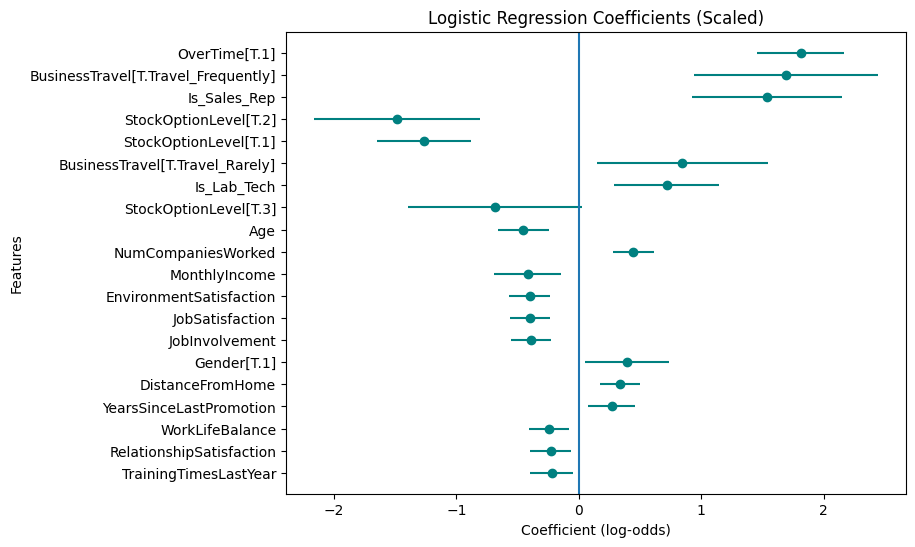

In [52]:
# достаём коэффициенты
coef = model_scaled.params
conf = model_scaled.conf_int()
conf.columns = ['lower', 'upper']

coef_df = pd.concat([coef, conf], axis=1)
coef_df.columns = ['coef', 'lower', 'upper']

# убираем константу
coef_df = coef_df.drop('Intercept')

# сортируем по модулю значимости
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values().index)

# строим график
plt.figure(figsize=(8,6))
plt.errorbar(coef_df['coef'], coef_df.index, 
             xerr=[coef_df['coef'] - coef_df['lower'], 
                   coef_df['upper'] - coef_df['coef']], 
             fmt='o',
             color='teal')

plt.axvline(0)
plt.title("Logistic Regression Coefficients (Scaled)")
plt.xlabel("Coefficient (log-odds)")
plt.ylabel("Features")
plt.show()

- там, где значение > 0: фактор увеличивает вероятность ухода
- там, где значение < 0: фактор уменьшает вероятность ухода
- там, где доверительный интервал пересекает 0: коэффициент не стат. значим (только у StockOptionLevel[T.3])

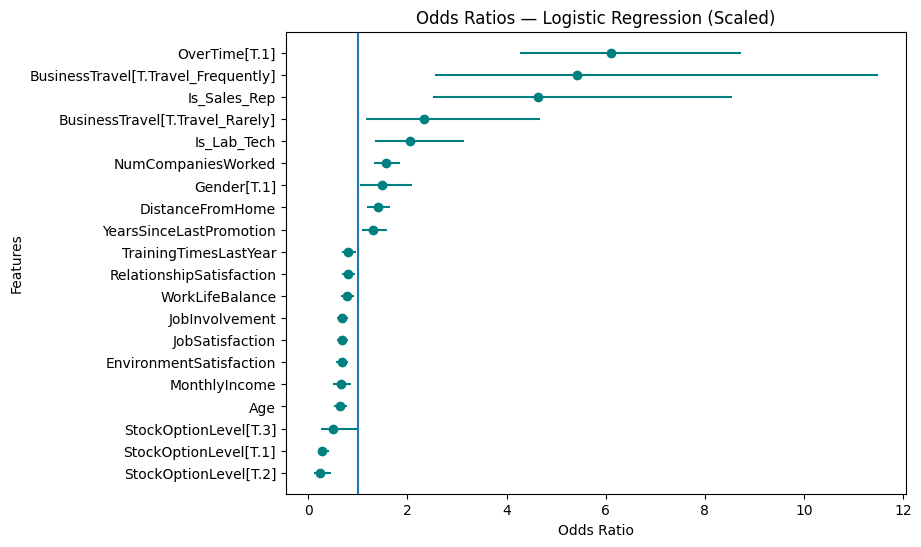

In [56]:
# переводим коэффициенты в odds ratio
odds = np.exp(model_scaled.params)
conf_odds = np.exp(model_scaled.conf_int())
conf_odds.columns = ['lower', 'upper']

odds_df = pd.concat([odds, conf_odds], axis=1)
odds_df.columns = ['odds_ratio', 'lower', 'upper']

odds_df = odds_df.drop('Intercept')
odds_df = odds_df.reindex(odds_df['odds_ratio'].sort_values().index)

plt.figure(figsize=(8,6))
plt.errorbar(odds_df['odds_ratio'], odds_df.index,
             xerr=[odds_df['odds_ratio'] - odds_df['lower'],
                   odds_df['upper'] - odds_df['odds_ratio']],
             fmt='o',
             color= 'teal')

plt.axvline(1)
plt.title("Odds Ratios — Logistic Regression (Scaled)")
plt.xlabel("Odds Ratio")
plt.ylabel("Features")
plt.show()

### Выделение подгрупп

Для обнаружения более склонных к увольнению сотрудников также оказался полезным метод **Subgroup Discovery**.

Задача Subgroup Discovery — выявить интерпретируемые подгруппы сотрудников, которые уволились из компании, и описать эти подгруппы в виде правил (сочетаний характеристик). В отличие от кластеризации, здесь Attrition напрямую используется как целевая переменная.

Для выделения подгрупп был применена библиотека pysubgroup. В качестве целевой переменной задан бинарный индикатор увольнения (Attrition_Yes = 1). Поиск подгрупп осуществлялся методом лучевого поиска, который итеративно расширяет наиболее перспективные правила, ограничивая их глубину. В качестве функции качества использовался хи-квадрат, что позволило выявить подгруппы, в которых доля уволившихся сотрудников статистически значимо отличается от средней по выборке. Этот подход помог обнаружить локальные закономерности, характерные для отдельных сегментов сотрудников.

In [5]:
!pip install pysubgroup

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 86.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import pysubgroup as ps

data = pd.read_csv("datasets/HR-Employee-Attrition.csv")
columns_to_drop = ['EducationField', 'JobRole', 'MaritalStatus', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'StockOptionLevel', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'DailyRate', 'HourlyRate','MonthlyRate']
data = data.drop(columns=columns_to_drop)
data = pd.get_dummies(data, columns = ['Attrition', 'BusinessTravel', 'Department', 'Gender', 'OverTime'], drop_first=True)

task1 = ps.SubgroupDiscoveryTask (
    data,
    ps.BinaryTarget("Attrition_Yes", target_value=1),
    ps.create_selectors(data, ignore=['Attrition_Yes']),
    result_set_size=10,
    depth=5,
    qf=ps.ChiSquaredQF()
)
ps.BeamSearch().execute(task1).to_dataframe()

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,171.382299,JobLevel==1 AND OverTime_Yes==True,156,1470,82,237,1314,0.106122,0.893878,0.345992,0.654008,0.525641,0.117960,0.161224,3.260305
1,149.931884,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,85,1470,54,237,1385,0.057823,0.942177,0.227848,0.772152,0.635294,0.132130,0.161224,3.940432
2,141.671731,MonthlyIncome<2696 AND OverTime_Yes==True,88,1470,54,237,1382,0.059864,0.940136,0.227848,0.772152,0.613636,0.132417,0.161224,3.806099
3,119.678301,Department_Sales==False AND JobLevel==1 AND Ov...,134,1470,66,237,1336,0.091156,0.908844,0.278481,0.721519,0.492537,0.127994,0.161224,3.054978
4,115.970676,JobLevel==1 AND OverTime_Yes==True AND YearsSi...,71,1470,44,237,1399,0.048299,0.951701,0.185654,0.814346,0.619718,0.137956,0.161224,3.843822
5,112.355815,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,45,1470,33,237,1425,0.030612,0.969388,0.139241,0.860759,0.733333,0.143158,0.161224,4.548523
6,111.543756,Department_Research & Development==True AND Jo...,126,1470,62,237,1344,0.085714,0.914286,0.261603,0.738397,0.492063,0.130208,0.161224,3.052039
7,111.543756,Department_Research & Development==True AND De...,126,1470,62,237,1344,0.085714,0.914286,0.261603,0.738397,0.492063,0.130208,0.161224,3.052039
8,111.106108,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,50,1470,35,237,1420,0.034014,0.965986,0.147679,0.852321,0.700000,0.142254,0.161224,4.341772
9,109.833722,Department_Sales==False AND JobLevel==1 AND Mo...,68,1470,42,237,1402,0.046259,0.953741,0.177215,0.822785,0.617647,0.139087,0.161224,3.830975


#### Интерпретация полученных правил

Общая доля увольнений в датасете составляет около 16%. Все выявленные подгруппы характеризуются существенно более высокой долей Attrition и высоким значением lift (от 3 до 4.5), что указывает на сильное отклонение от среднего уровня текучести.

- **JobLevel = 1 AND OverTime = Yes:** Доля увольнений в подгруппе: 52.6%. Сотрудники начального уровня, работающие сверхурочно, увольняются значительно чаще, чем в среднем по компании.
- **JobLevel = 1 AND MonthlyIncome < 2696 AND OverTime = Yes:** Доля увольнений: 63–64%. Добавление низкого дохода существенно усиливает эффект: сочетание начального уровня должности, сверхурочной работы и низкой зарплаты формирует крайне уязвимую подгруппу.
- **JobLevel = 1 AND OverTime = Yes AND YearsSinceLastPromotion: [0;1):** Доля увольнений: 62%. Недавнее повышение не компенсирует негативный эффект перегрузки и низкого уровня должности.
- **Department_Research & Development = True AND JobLevel = 1 AND OverTime = Yes:** Доля увольнений: 49.2%. Сотрудники отдела R&D с низким уровнем должности и переработками особенно склонны к увольнениям. (В группе достаточно много человек — 126.)
- **JobLevel = 1 AND MonthlyIncome < 2696 AND OverTime = Yes AND WorkLifeBalance = 3:** Доля увольнений: 70%. Даже относительно нормальный уровень WorkLifeBalance не снижает риск ухода, если присутствуют переработки, низкий доход и начальный уровень должности. Это подчёркивает доминирующую роль нагрузки и оплаты труда.
Все группы получились достаточно большими.

In [11]:
small_data = data.copy()
col_drop = ['TotalWorkingYears', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales']
small_data = small_data.drop(columns=col_drop)

task2 = ps.SubgroupDiscoveryTask (
    small_data,
    ps.BinaryTarget("Attrition_Yes", target_value=1),
    ps.create_selectors(small_data, ignore=['Attrition_Yes']),
    result_set_size=10,
    depth=3,
    qf=ps.ChiSquaredQF()
)
ps.BeamSearch().execute(task2).to_dataframe()

,quality,subgroup,size_sg,size_dataset,positives_sg,positives_dataset,size_complement,relative_size_sg,relative_size_complement,coverage_sg,coverage_complement,target_share_sg,target_share_complement,target_share_dataset,lift
0,171.382299,JobLevel==1 AND OverTime_Yes==True,156,1470,82,237,1314,0.106122,0.893878,0.345992,0.654008,0.525641,0.117960,0.161224,3.260305
1,149.931884,JobLevel==1 AND MonthlyIncome<2696 AND OverTim...,85,1470,54,237,1385,0.057823,0.942177,0.227848,0.772152,0.635294,0.132130,0.161224,3.940432
2,141.671731,MonthlyIncome<2696 AND OverTime_Yes==True,88,1470,54,237,1382,0.059864,0.940136,0.227848,0.772152,0.613636,0.132417,0.161224,3.806099
3,115.970676,JobLevel==1 AND OverTime_Yes==True AND YearsSi...,71,1470,44,237,1399,0.048299,0.951701,0.185654,0.814346,0.619718,0.137956,0.161224,3.843822
4,105.044324,MonthlyIncome<2696 AND OverTime_Yes==True AND ...,47,1470,33,237,1423,0.031973,0.968027,0.139241,0.860759,0.702128,0.143359,0.161224,4.354969
5,104.437686,MonthlyIncome<2696 AND OverTime_Yes==True AND ...,52,1470,35,237,1418,0.035374,0.964626,0.147679,0.852321,0.673077,0.142454,0.161224,4.174781
6,102.187524,JobLevel==1 AND OverTime_Yes==True AND WorkLif...,88,1470,48,237,1382,0.059864,0.940136,0.202532,0.797468,0.545455,0.136758,0.161224,3.383199
7,99.864480,Age<29 AND JobLevel==1 AND OverTime_Yes==True,56,1470,36,237,1414,0.038095,0.961905,0.151899,0.848101,0.642857,0.142150,0.161224,3.987342
8,96.368605,Gender_Male==True AND JobLevel==1 AND OverTime...,97,1470,50,237,1373,0.065986,0.934014,0.210970,0.789030,0.515464,0.136198,0.161224,3.197181
9,93.787411,Gender_Male==True AND MonthlyIncome<2696 AND O...,53,1470,34,237,1417,0.036054,0.963946,0.143460,0.856540,0.641509,0.143260,0.161224,3.978983


Выделение подгрупп на меньшем количестве характеристик наблюдений с меньшей глубиной правил выявляет дополнительные правила, связанные с полом и возрастом (но возраст умеренно коррелирует с уровнем должности JobLevel):
- **Gender = Male AND JobLevel = 1 AND OverTime = Yes:** Доля увольнений: 51.6%
- **Gender = Male AND MonthlyIncome < 2696 AND OverTime = Yes:** Доля увольнений: 64.2%
- **Age < 29 AND JobLevel = 1 AND OverTime = Yes:** Доля увольнений: 64.3%

#### Полезность для основной задачи

Выявленные правила подтверждают и уточняют результаты регрессионного анализа, показывая не только направление влияния факторов, но и более полные сценарии, при которых вероятность ухода становится достаточно высокой.

Метод Subgroup Discovery позволяет выявлять подгруппы риска, за которыми стоит наблюдать. Правила легко интерпретируются и могут быть использованы в коммуникации с HR и менеджментом.

### Предсказательная модель логистической регрессии

Дополнительно мы хотим узнать, какие факторы будут важными для предсказания целевой переменной Attrition, для этого построим предсказательную модель и посмотрим насколько выявленные факторы соотнесутся с нашими основными выводами\.

In [18]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics

data = pd.read_csv("datasets/HR-Employee-Attrition.csv")
columns_to_drop = ['EducationField', 'JobRole', 'PerformanceRating', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'HourlyRate', 'MonthlyRate']
data = data.drop(columns=columns_to_drop)
data = pd.get_dummies(data, columns = ['Attrition', 'BusinessTravel', 'Department', 'Gender', 'OverTime', 'MaritalStatus'], drop_first=True)

Далее задача формулируется как задача классификации: предсказать, уйдёт ли сотрудник\.

Из\-за дисбаланса классов \(16% ушли, 84% остались\) основная метрика — F1\-score, а не accuracy\.

In [19]:
y = data["Attrition_Yes"]
X = data.drop(columns="Attrition_Yes")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Так как в процессе выполнения дневников было выяснено, что лучшая предсказательная сила у всё той же модели логистической регрессии, то большой разницы в результатах не будет, но эта модель была построена на бОльшем количестве признаков, в отличие от регрессии для инференс\-задачи\.

In [20]:
from sklearn.linear_model import LogisticRegression

logC = LogisticRegression(solver = "liblinear", max_iter=1000)
logC.fit(X_train, y_train)

logC.score(X_train, y_train), logC.score(X_test, y_test)

(0.8744897959183674, 0.8857142857142857)

Accuracy\. Train: 0\.874\. Test: 0\.886\. Модель не переобучена — на новых данных работает даже чуть лучше, чем на обучающих\. Точность не сильно выше, чем предсказание всем одного класса "No", но всё\-таки лучше этого\.

In [21]:
log_pred = logC.predict(X_test)
metrics.confusion_matrix(y_test, log_pred)

array([[408,   3],
       [ 53,  26]])

- TN = 408 — корректно предсказали тех, кто не ушёл
- FP = 3 — ошибочно предсказали, что они уйдут
- FN = 53 — пропустили сотрудников, которые на самом деле ушли
- TP = 26 — корректно нашли ушедших

In [22]:
metrics.f1_score(y_test, log_pred, pos_label=True)

0.48148148148148145

F1\-score \(класс yes\) = 0\.48\. Значительно лучше, чем у всех остальных моделей, но есть куда стремиться, очень хорошей модель не назовёшь, она всё ещё пропускает слишком много ушедших сотрудников\. Более сложные ансамблевые модели не давали выигрыша в качестве, как и дерево, поэтому модель регрессия была выбрана для приведения в отчёте как самая качественная и интерпретируемая\. Кажется, что она всё равно могла бы послужить помощником в идентификации сотрудников, которые могут покинуть компанию\. Теперь посмотрим интерпретацию модели \(коэффициенты регрессии\), оценим важность признаков для предсказания целевой переменной с точки зрения этой модели\.

Глобальная интерпретация модели

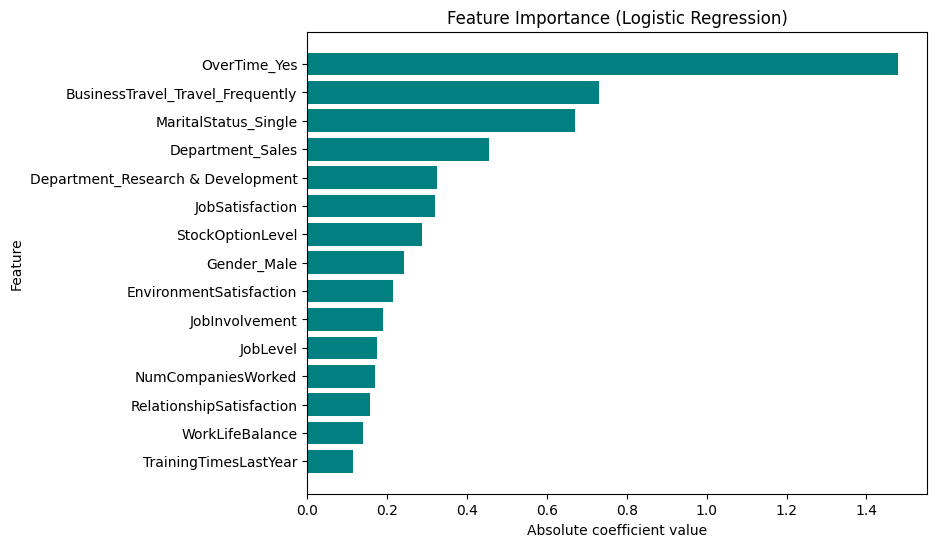

In [23]:
coefficients = logC.coef_[0]
importance_df = pd.DataFrame({"feature": X.columns, "importance": np.abs(coefficients)})
importance_df = importance_df.sort_values(by="importance", ascending=False)

top_n = 15

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df.head(top_n)["feature"][::-1],
    importance_df.head(top_n)["importance"][::-1],
    color='teal'
)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Absolute coefficient value")
plt.ylabel("Feature")
plt.show()

Как и ожидалось, больше всего на предсказание влияют переработки и частые командировки, что согласуется с результатами предыдущего анализа\. Дополнительно модель выделяет семейное положение \(одиноких людей\) как значимый фактор\. При этом было проверено, что коэффициент при данной переменной стат\. значим, тогда как коэффициенты при Gender\_Male и Department\_Sales не являются значимыми\. Это расхождение с инференс\-моделью может быть связано с наличием мультиколлинеарности и тем, что в модели одновременно учитывается большое количество взаимосвязанных признаков, из\-за чего вклад отдельных переменных может изменяться\.

In [24]:
importance_df.head(10)

,feature,importance
25,OverTime_Yes,1.478015
20,BusinessTravel_Travel_Frequently,0.730947
27,MaritalStatus_Single,0.671315
23,Department_Sales,0.454984
22,Department_Research & Development,0.324725
7,JobSatisfaction,0.319244
12,StockOptionLevel,0.286735
24,Gender_Male,0.242852
4,EnvironmentSatisfaction,0.215290
5,JobInvolvement,0.189939


Проверка стат\. значимости:

In [25]:
features = X_train.columns
formula = "Attrition_Yes ~ " + " + ".join([f'Q("{col}")' for col in features])

data_sm = X_train.copy()
data_sm["Attrition_Yes"] = y_train.astype(int)

model = sm.logit(formula, data=data_sm)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.295938
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          Attrition_Yes   No. Observations:                  980
Model:                          Logit   Df Residuals:                      951
Method:                           MLE   Df Model:                           28
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                  0.3300
Time:                        13:31:45   Log-Likelihood:                -290.02
converged:                       True   LL-Null:                       -432.86
Covariance Type:            nonrobust   LLR p-value:                 1.678e-44
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                           

### Итоговые выводы проекта
1. Текучесть кадров определяется совокупностью факторов, а не одной переменной.
2. Наиболее важные факторы: переработки, частые командировки, удовлетворённость работой, отдел, уровень дохода, уровень должности, карьерный рост.
3. Наиболее уязвимая группа: сотрудники начального уровня с переработками от высокой нагрузки, с низким доходом, с ограниченными карьерными перспективами.
4. Предсказательная модель (логистическая регрессия) показывает удовлетворительное качество и подтверждает результаты анализа. Она может быть использована для раннего выявления сотрудников с высоким риском ухода.
5. Использование более сложных моделей (ансамблей и нейросетей) не дало существенного выигрыша в метриках, что делает логистическую регрессию оптимальным выбором для задачи предсказания, но не всех захотящих уволиться сотрудников модель сможет обнаружить вовремя.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ff5c65e0-9edf-47b2-8d5a-439e7f5c1ece' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>